# Accessing Databases with SQL Magic

## Objective
In this lab, I will:
- Load the SQL extension in a notebook
- Connect to a SQLite database
- Create and populate a table using SQL Magic
- Run SQL queries directly in the notebook
- Use Python variables inside SQL statements
- Store query results in Python variables
- Convert query results into a DataFrame

## Step 1: Install and Load SQL Magic

In this step, I install and load the SQL extension so I can run SQL directly inside Google Colab using `%sql` and `%%sql`.

In [ ]:
!pip install ipython-sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.4 MB/s eta 0:00:00


In [ ]:
%load_ext sql

## Step 2: Connect to a SQLite Database

Here I connect to a SQLite database using SQL Magic.

If the database does not already exist, it will be created automatically.

In [ ]:
%sql sqlite:///SQLMagic.db

## Step 3: Create the Table

Next, I create a table called `INTERNATIONAL_STUDENT_TEST_SCORES`.

This table stores student names, country, and test score.

In [ ]:
%%sql

CREATE TABLE INTERNATIONAL_STUDENT_TEST_SCORES (
    country VARCHAR(50),
    first_name VARCHAR(50),
    last_name VARCHAR(50),
    test_score INTEGER
);

 * sqlite:///SQLMagic.db
Done.


[]

## Step 4: Insert Sample Data

Now I insert sample student records into the table.

This gives me data to query and analyze.

In [ ]:
%%sql

INSERT INTO INTERNATIONAL_STUDENT_TEST_SCORES (country, first_name, last_name, test_score)
VALUES
('Canada', 'Sophie', 'Martin', 88),
('Canada', 'Liam', 'Taylor', 92),
('India', 'Aarav', 'Patel', 81),
('India', 'Anika', 'Sharma', 95),
('United States', 'Noah', 'Walker', 78),
('United States', 'Emma', 'Hall', 85),
('United Kingdom', 'Olivia', 'White', 90),
('Australia', 'Lucas', 'Brown', 84),
('Germany', 'Mia', 'Schmidt', 87),
('France', 'Leo', 'Dubois', 80);

 * sqlite:///SQLMagic.db
10 rows affected.


[]

## Step 5: View the Data

I use a SELECT statement to display all rows in the table.

In [ ]:
!pip uninstall -y prettytable ipython-sql
!pip install prettytable==3.11.0 ipython-sql

Found existing installation: prettytable 3.17.0
Uninstalling prettytable-3.17.0:
  Successfully uninstalled prettytable-3.17.0
Found existing installation: ipython-sql 0.5.0
Uninstalling ipython-sql-0.5.0:
  Successfully uninstalled ipython-sql-0.5.0


In [1]:
%load_ext sql

In [2]:
%sql sqlite:///SQLMagic.db

In [3]:
%%sql
SELECT * FROM INTERNATIONAL_STUDENT_TEST_SCORES;

 * sqlite:///SQLMagic.db
Done.


country,first_name,last_name,test_score
Canada,Sophie,Martin,88
Canada,Liam,Taylor,92
India,Aarav,Patel,81
India,Anika,Sharma,95
United States,Noah,Walker,78
United States,Emma,Hall,85
United Kingdom,Olivia,White,90
Australia,Lucas,Brown,84
Germany,Mia,Schmidt,87
France,Leo,Dubois,80


## Step 6: View a Limited Number of Rows

To make the output easier to read, I can limit the number of rows returned by the query.

In [4]:
%%sql
SELECT *
FROM INTERNATIONAL_STUDENT_TEST_SCORES
LIMIT 5;

 * sqlite:///SQLMagic.db
Done.


country,first_name,last_name,test_score
Canada,Sophie,Martin,88
Canada,Liam,Taylor,92
India,Aarav,Patel,81
India,Anika,Sharma,95
United States,Noah,Walker,78


## Step 7: Count the Number of Records

This query counts how many student records are stored in the table.

In [5]:
%%sql
SELECT COUNT(*) AS total_students
FROM INTERNATIONAL_STUDENT_TEST_SCORES;

 * sqlite:///SQLMagic.db
Done.


total_students
10


COUNT(*) counts all rows in the table, and I renamed the result as total_students.

## Step 8: Use a Python Variable in a SQL Query

SQL Magic allows me to use a Python variable inside a SQL query. This makes the query more dynamic and reusable.

In [6]:
country = "Canada"

In [7]:
%%sql
SELECT *
FROM INTERNATIONAL_STUDENT_TEST_SCORES
WHERE country = '$country';

 * sqlite:///SQLMagic.db
Done.


country,first_name,last_name,test_score


Here I created a Python variable called country and used it inside the SQL query to return only rows for Canada.

## Step 9: Store SQL Query Results in a Python Variable

I can save the output of a SQL query into a Python variable so I can use it later in Python.

In [8]:
%%sql test_score_distribution <<
SELECT test_score, COUNT(*) AS frequency
FROM INTERNATIONAL_STUDENT_TEST_SCORES
GROUP BY test_score
ORDER BY test_score;

 * sqlite:///SQLMagic.db
Done.
Returning data to local variable test_score_distribution


This query groups the records by test_score, counts how many students got each score, and stores the results in a Python variable called test_score_distribution.

## Step 10: Display the Stored Query Results

Now I display the query results that were saved into the Python variable.

In [9]:
test_score_distribution

test_score,frequency
78,1
80,1
81,1
84,1
85,1
87,1
88,1
90,1
92,1
95,1


## Step 11: Convert SQL Results to a DataFrame

I convert the SQL results into a pandas-style DataFrame so I can work with the data more easily.

In [10]:
dataframe = test_score_distribution.DataFrame()
dataframe

,test_score,frequency
0,78,1
1,80,1
2,81,1
3,84,1
4,85,1
5,87,1
6,88,1
7,90,1
8,92,1
9,95,1


The .DataFrame() method converts the SQL result into a tabular format that is easier to analyze and visualize.

## Step 12: Prepare for Visualization

I import visualization libraries so I can create a chart from the SQL query results.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

## Step 13: Visualize the Test Score Distribution

This bar chart shows how many students received each test score.

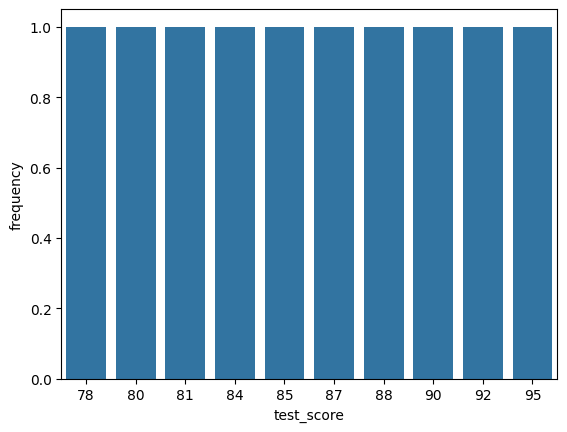

In [12]:
sns.barplot(x='test_score', y='frequency', data=dataframe)
plt.show()

This chart helps visualize the frequency of each test score in the dataset.

## Step 14: Run a Final Query

This query displays selected columns from the table in a clean format.

In [13]:
%%sql
SELECT country, first_name, last_name, test_score
FROM INTERNATIONAL_STUDENT_TEST_SCORES;

 * sqlite:///SQLMagic.db
Done.


country,first_name,last_name,test_score
Canada,Sophie,Martin,88
Canada,Liam,Taylor,92
India,Aarav,Patel,81
India,Anika,Sharma,95
United States,Noah,Walker,78
United States,Emma,Hall,85
United Kingdom,Olivia,White,90
Australia,Lucas,Brown,84
Germany,Mia,Schmidt,87
France,Leo,Dubois,80


## Conclusion

In this lab, I used SQL Magic within Google Colab to interact with a SQLite database directly using SQL queries.

I created and queried a table, filtered data using conditions, counted records, and grouped results to analyze test score distributions. I also demonstrated how to use Python variables within SQL queries and how to store query results in Python variables.

Finally, I converted the SQL results into a DataFrame and visualized the data using a bar chart. This lab showed how SQL and Python can work together in a notebook environment for data analysis and visualization.

This lab demonstrates how SQL and Python can be combined in a notebook environment to query, analyze, and visualize data efficiently.

This approach is useful in real-world data analysis workflows where SQL is used for data extraction and Python is used for analysis and visualization.